In [3]:
!pip install yfinance scikit-learn matplotlib pandas numpy

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------------------- -------------------- 0.8/1.6 MB 2.8 MB/s eta 0:00:01
   -------------------------------- ------- 1.3/1.6 MB 2.6 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 2.2 MB/s  0:00:00
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15702 sha256=e6e124f94079f8d8226dad897021c0317decae977a155ab436ab184fdc17e646
  Stored in directory: c:\users\dell\appdata\local\pip\cache\wheels\cc\bd\6

In [4]:
import sys
!{sys.executable} -m pip install yfinance scikit-learn matplotlib pandas numpy

'C:\Users\Dell\Documents\New' is not recognized as an internal or external command,
operable program or batch file.


[*********************100%***********************]  1 of 1 completed

✅ Libraries imported successfully!
✅ Downloaded 752 rows for TSLA
Price            Close        High         Low        Open    Volume
Ticker            TSLA        TSLA        TSLA        TSLA      TSLA
Date                                                                
2024-12-23  430.600006  434.510010  415.410004  431.000000  72698100
2024-12-24  462.279999  462.779999  435.140015  435.899994  59551800
2024-12-26  454.130005  465.329987  451.019989  465.160004  76366400
2024-12-27  431.660004  450.000000  426.500000  449.519989  82666800
2024-12-30  417.410004  427.000000  415.750000  419.399994  64941000
✅ Features: ['Open', 'High', 'Low', 'Volume']
   Samples: 751
✅ Train size: 450 | Test size: 301


✅ Both models trained!

📊 Linear Regression
   MAE  : $6.77
   RMSE : $9.89
   R²   : 0.9764

📊 Random Forest
   MAE  : $10.17
   RMSE : $18.32
   R²   : 0.9191


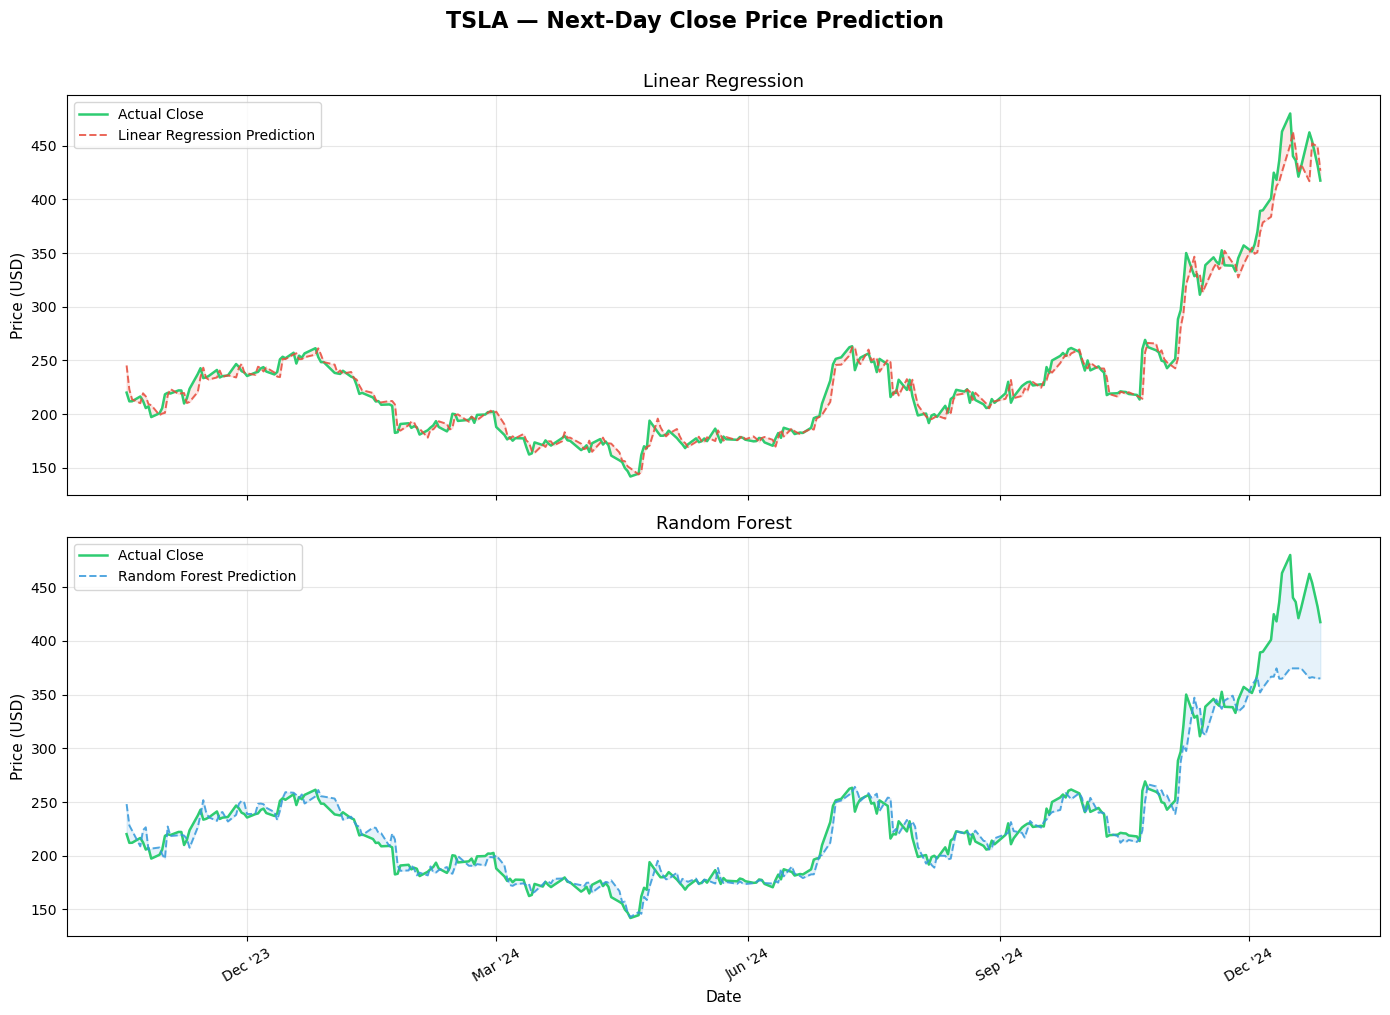

✅ Plot saved as stock_prediction.png

🔮 Predicted NEXT closing price for TSLA:
   Linear Regression : $426.51
   Random Forest     : $365.05
   Average           : $395.78


In [16]:
# ============================================================
# Task 2: Stock Price Prediction (Short-Term)
# Jupyter Notebook Ready — Copy each cell block separately
# ============================================================

# ──────────────────────────────────────────
# CELL 1 — Library Install (run once)
# ──────────────────────────────────────────
# !pip install yfinance scikit-learn matplotlib pandas numpy

# ──────────────────────────────────────────
# CELL 2 — Imports
# ──────────────────────────────────────────
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

print("✅ Libraries imported successfully!")

# ──────────────────────────────────────────
# CELL 3 — Load Stock Data from Yahoo Finance
# ──────────────────────────────────────────
STOCK = "TSLA"
START = "2022-01-01"
END   = "2024-12-31"

df = yf.download(STOCK, start=START, end=END)
df.dropna(inplace=True)

print(f"✅ Downloaded {len(df)} rows for {STOCK}")
print(df.tail())

# ──────────────────────────────────────────
# CELL 4 — Feature Engineering
# ──────────────────────────────────────────
# Features: Open, High, Low, Volume → Predict: Next Day's Close

df["Target"] = df["Close"].shift(-1)   # Next day's closing price
df.dropna(inplace=True)

features = ["Open", "High", "Low", "Volume"]
X = df[features].values
y = df["Target"].values.ravel()

print(f"✅ Features: {features}")
print(f"   Samples: {X.shape[0]}")

# ──────────────────────────────────────────
# CELL 5 — Train / Test Split (60 / 40)
# ──────────────────────────────────────────
SPLIT = int(len(X) * 0.60)

X_train, X_test = X[:SPLIT], X[SPLIT:]
y_train, y_test = y[:SPLIT], y[SPLIT:]
dates_test = df.index[SPLIT:]

print(f"✅ Train size: {len(X_train)} | Test size: {len(X_test)}")

# ──────────────────────────────────────────
# CELL 6 — Train Models
# ──────────────────────────────────────────

# --- Linear Regression ---
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

# --- Random Forest ---
rf_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("✅ Both models trained!")

# ──────────────────────────────────────────
# CELL 7 — Evaluation Metrics
# ──────────────────────────────────────────
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"\n📊 {name}")
    print(f"   MAE  : ${mae:.2f}")
    print(f"   RMSE : ${rmse:.2f}")
    print(f"   R²   : {r2:.4f}")

evaluate("Linear Regression", y_test, lr_pred)
evaluate("Random Forest",     y_test, rf_pred)

# ──────────────────────────────────────────
# CELL 8 — Plot: Actual vs Predicted
# ──────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
fig.suptitle(f"{STOCK} — Next-Day Close Price Prediction", fontsize=16, fontweight="bold", y=1.01)

colors = {
    "actual" : "#2ecc71",
    "lr"     : "#e74c3c",
    "rf"     : "#3498db",
}

for ax, (model_name, pred) in zip(axes, [
    ("Linear Regression", lr_pred),
    ("Random Forest",     rf_pred),
]):
    ax.plot(dates_test, y_test, label="Actual Close",  color=colors["actual"], linewidth=1.8)
    ax.plot(dates_test, pred,   label=f"{model_name} Prediction",
            color=colors["lr"] if "Linear" in model_name else colors["rf"],
            linewidth=1.4, linestyle="--", alpha=0.85)

    ax.fill_between(dates_test, y_test, pred,
                    alpha=0.12,
                    color=colors["lr"] if "Linear" in model_name else colors["rf"])

    ax.set_title(model_name, fontsize=13)
    ax.set_ylabel("Price (USD)", fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))

plt.xticks(rotation=30)
plt.xlabel("Date", fontsize=11)
plt.tight_layout()
plt.savefig("stock_prediction.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plot saved as stock_prediction.png")

# ──────────────────────────────────────────
# CELL 9 — Predict TOMORROW'S Price
# ──────────────────────────────────────────
latest = df[features].iloc[-1].values.reshape(1, -1)

lr_tomorrow = lr_model.predict(latest)[0]
rf_tomorrow = rf_model.predict(latest)[0]

print(f"\n🔮 Predicted NEXT closing price for {STOCK}:")
print(f"   Linear Regression : ${lr_tomorrow:.2f}")
print(f"   Random Forest     : ${rf_tomorrow:.2f}")
print(f"   Average           : ${(lr_tomorrow + rf_tomorrow) / 2:.2f}")

In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
import time
import numpy as np
from sklearn.metrics import r2_score as r2

# Standard Scaler
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ════════════════════════════════════════
# [1] LINEAR REGRESSION
# ════════════════════════════════════════
print("=" * 50)
print("  [1] Training: Linear Regression...")
print("=" * 50)
t1 = time.time()
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
print(f"  Done!  Time: {time.time()-t1:.2f}s")
print(f"  Note: Linear Regression has no Epochs")
print(f"  Note: It solves mathematically in ONE step")

# ════════════════════════════════════════
# [2] RANDOM FOREST
# ════════════════════════════════════════
print("\n" + "=" * 50)
print("  [2] Training: Random Forest (200 Trees)...")
print("=" * 50)

rf_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1, warm_start=True)
checkpoints = [10, 25, 50, 75, 100, 125, 150, 175, 200]

t2 = time.time()
for i, n in enumerate(checkpoints):
    rf_model.n_estimators = n
    rf_model.fit(X_train, y_train)
    temp_pred = rf_model.predict(X_test)
    temp_r2   = r2(y_test, temp_pred)
    mape      = np.mean(np.abs((y_test - temp_pred) / y_test)) * 100
    acc       = 100 - mape
    bar       = "█" * (i+1) + "░" * (8-i)
    print(f"  Trees: {n:>3} [{bar}]  Acc: {acc:.2f}%  R2: {temp_r2:.4f}")

rf_pred = rf_model.predict(X_test)
print(f"  Done!  Time: {time.time()-t2:.2f}s")

# ════════════════════════════════════════
# [3] NEURAL NETWORK (Real Epochs)
# ════════════════════════════════════════
print("\n" + "=" * 50)
print("  [3] Training: Neural Network (Real Epochs)")
print("=" * 50)

EPOCHS = 200

nn_model = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    max_iter=1,
    warm_start=True,
    random_state=42,
    learning_rate_init=0.001
)

epoch_list, loss_list, acc_list = [], [], []
t3 = time.time()

for epoch in range(1, EPOCHS + 1):
    nn_model.max_iter = epoch
    nn_model.fit(X_train_sc, y_train)
    nn_pred_temp = nn_model.predict(X_test_sc)
    mape = np.mean(np.abs((y_test - nn_pred_temp) / y_test)) * 100
    acc  = 100 - mape
    loss = nn_model.loss_

    epoch_list.append(epoch)
    loss_list.append(loss)
    acc_list.append(acc)

    if epoch in [1, 10, 25, 50, 75, 100, 125, 150, 175, 200]:
        bar = "█" * int(epoch/25) + "░" * (8 - int(epoch/25))
        print(f"  Epoch {epoch:>3}/{EPOCHS} [{bar}]  Loss: {loss:.4f}  Acc: {acc:.2f}%")

nn_pred = nn_model.predict(X_test_sc)
print(f"  Done!  Time: {time.time()-t3:.2f}s")
print("\n All 3 Models Trained Successfully!")

  [1] Training: Linear Regression...
  Done!  Time: 0.00s
  Note: Linear Regression has no Epochs
  Note: It solves mathematically in ONE step

  [2] Training: Random Forest (200 Trees)...
  Trees:  10 [█░░░░░░░░]  Acc: 95.05%  R2: 0.8771
  Trees:  25 [██░░░░░░░]  Acc: 95.25%  R2: 0.8910
  Trees:  50 [███░░░░░░]  Acc: 95.32%  R2: 0.8891
  Trees:  75 [████░░░░░]  Acc: 95.37%  R2: 0.8909
  Trees: 100 [█████░░░░]  Acc: 95.44%  R2: 0.8921
  Trees: 125 [██████░░░]  Acc: 95.46%  R2: 0.8945
  Trees: 150 [███████░░]  Acc: 95.46%  R2: 0.8959
  Trees: 175 [████████░]  Acc: 95.48%  R2: 0.8960
  Trees: 200 [█████████]  Acc: 95.48%  R2: 0.8965
  Done!  Time: 1.17s

  [3] Training: Neural Network (Real Epochs)
  Epoch   1/200 [░░░░░░░░]  Loss: 28096.9319  Acc: 0.18%
  Epoch  10/200 [░░░░░░░░]  Loss: 2777.2559  Acc: 72.37%
  Epoch  25/200 [█░░░░░░░]  Loss: 44.3625  Acc: 96.82%
  Epoch  50/200 [██░░░░░░]  Loss: 43.7790  Acc: 96.79%
  Epoch  75/200 [███░░░░░]  Loss: 44.0076  Acc: 96.47%
  Epoch 100/200

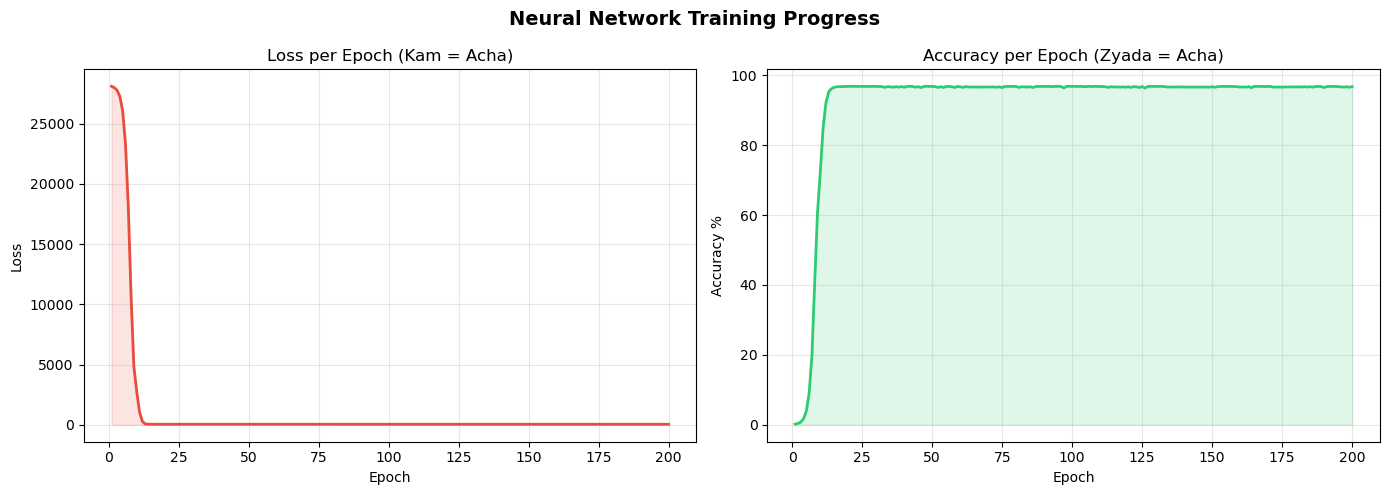

Epoch graph saved!


In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Neural Network Training Progress", fontsize=14, fontweight="bold")

ax1.plot(epoch_list, loss_list, color="#e74c3c", linewidth=2)
ax1.fill_between(epoch_list, loss_list, alpha=0.15, color="#e74c3c")
ax1.set_title("Loss per Epoch (Kam = Acha)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.grid(True, alpha=0.3)

ax2.plot(epoch_list, acc_list, color="#2ecc71", linewidth=2)
ax2.fill_between(epoch_list, acc_list, alpha=0.15, color="#2ecc71")
ax2.set_title("Accuracy per Epoch (Zyada = Acha)")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy %")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("epoch_training.png", dpi=150, bbox_inches="tight")
plt.show()
print("Epoch graph saved!")